In [1]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
import torch.nn as nn

In [2]:
from training.train_mlm import download_model_and_config, load_model
import einops

In [3]:
from torch.utils.data import DataLoader
from generators.subseries_converter import EchoStateDataset
from models.vanila_decoder_transformer import TransformerDecoderModel
from statsmodels.tsa.arima.model import ARIMA
from tqdm import tqdm

model_path, config = download_model_and_config('8mrjpiu1')
model = load_model(model_path, config)
model.to('cuda')
model_benchmark = TransformerDecoderModel(config=config)
model_benchmark.to('cuda')
model_benchmark.eval()
config['dataset']['train']['num_series'] = 1000
# config['dataset']['train']['series_length'] = 200
dataset_config = config.get('dataset', {})
train_dataset = EchoStateDataset(config=config, training=True, input_label=True)
val_dataset = EchoStateDataset(config=config, training=False, input_label=True)
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=False
)
val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False
)

wandb: Using wandb-core as the SDK backend. Please refer to https://wandb.me/wandb-core for more information.
wandb:   1 of 1 files downloaded.  
/home/wojciech/private/magisterka/TFTS/training/train_mlm.py:70: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Pl

Downloaded model: /home/wojciech/private/magisterka/TFTS/notebooks/artifacts/model-8mrjpiu1:v52/model.ckpt


In [4]:
import numpy as np

In [5]:
samples = []
for i in tqdm(range(len(train_dataset))):
    x, y = train_dataset[i]
    samples.append(x)

  0%|          | 0/1000 [00:00<?, ?it/s]/home/wojciech/private/magisterka/TFTS/generators/subseries_converter.py:174: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ../torch/csrc/utils/tensor_new.cpp:278.)
  label = torch.tensor(self.esn.input)
100%|██████████| 1000/1000 [00:22<00:00, 45.14it/s]


In [6]:
samples_tensor = torch.hstack(samples).shape

In [7]:
# Calculate the correlation matrix of samples_tensor
samples_tensor = torch.hstack(samples)
correlation_matrix = torch.corrcoef(samples_tensor)

In [8]:
import seaborn as sns

In [36]:
import torch
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

x, _ = next(iter(train_loader))
x = x[0:1].to('cuda')
T        = x.size(1)
mid_idx  = T // 2
x_masked = x.clone()  # Create a copy of the input tensor
masked_tokens = np.array([50])
x_masked[:, masked_tokens, :] = 0
mask_col = torch.zeros(x.shape[1])
mask_col[masked_tokens] = 1
mask_col = mask_col.unsqueeze(0).expand(x.shape[0], -1).unsqueeze(-1).to('cuda')
x_masked = torch.cat([x_masked, mask_col], dim=-1)
seq_len=100

attn_layers = []                      # each element → (H, T, T)

def make_hook():
    """
    Capture attn weights from MultiheadAttention.
    Works for all modern PyTorch versions.
    """
    def _hook(m, _inp, out):
        weights = out[1] if isinstance(out, (tuple, list)) else out
        H = m.num_heads
        weights = weights.detach().cpu()
        weights = weights.view(1, T, T)

        attn_layers.append(weights)
    return _hook

handles = []
for layer in model.transformer_encoder.layers:
    handles.append(layer.self_attn.register_forward_hook(make_hook()))

all_contrib = []
it = iter(train_loader)
for i in tqdm(range(1000)):
    x, _ = train_dataset[i]
    x = x.unsqueeze(0).to('cuda')
    x_masked = x.clone()  # Create a copy of the input tensor
    masked_tokens = np.array([60])
    x_masked[:, masked_tokens, :] = 0
    mask_col = torch.zeros(x.shape[1])
    mask_col[masked_tokens] = 1
    mask_col = mask_col.unsqueeze(0).expand(x.shape[0], -1).unsqueeze(-1).to('cuda')
    x_masked = torch.cat([x_masked, mask_col], dim=-1)

    attn_layers.clear()
    model.eval()
    with torch.no_grad():
        _ = model(x_masked)
    A_prop = None
    for A in attn_layers:
        A = A.mean(dim=0)
        A = A + torch.eye(T)
        A = A / A.sum(dim=-1, keepdim=True)
        A_prop = A if A_prop is None else A @ A_prop
    token_contrib = A_prop[60].numpy()     # (T,)
    all_contrib.append(token_contrib)


for h in handles:
    h.remove()

100%|██████████| 1000/1000 [00:23<00:00, 42.93it/s]


In [37]:
for h in handles:
    h.remove()

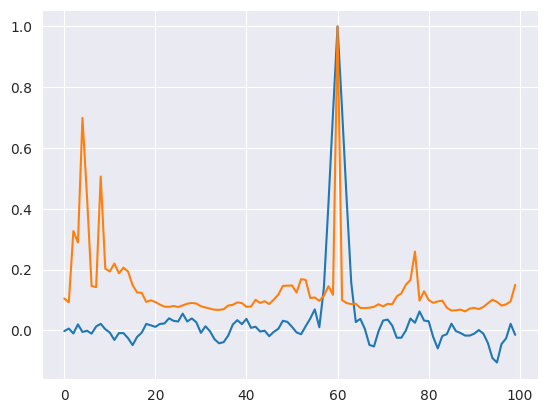

In [38]:
plt.plot(correlation_matrix[60, :])
plt.plot(np.mean(np.vstack(all_contrib), axis=0)/np.max(np.mean(np.vstack(all_contrib), axis=0)))